##**행렬 분해를 이용한 잠재 요인 협업 필터링 실습**

- 행렬 분해 잠재 요인 협업 필터링은 SVD나 NMF 등을 적용할 수 있음
- 일반적으로 행렬 분해에는 SVD가 자주 사용되지만
- 사용자ㅡ아이템 평점 행렬에는 사용자가 평점을 매기지 않은 널 데이터가 많기 때문에 주로 SGD나 ALS 기반의 행렬 분해를 이용

In [1]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
  error = 0
  for i, j, r in non_zeros:
    pred = np.dot(P[i, :], Q[j, :].T)
    error += pow(r - pred, 2)
    rmse = np.sqrt(error / len(non_zeros))

    return rmse

In [2]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01 ):
  num_users, num_items = R.shape
  # P와 Q 매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력합니다.
  np.random.seed(1)
  P = np.random.normal(scale=1./K, size=(num_users, K))
  Q = np.random.normal(scale=1./K, size=(num_items, K))

  # R 〉0 인 행 위치, 열 위치, 값을 non.zeros 리스트 객체에 저장.
  non_zeros = [ (i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] > 0 ]

  # SGD기법으로 P와 Q 매트릭스를 계속 업데이트.
  for step in range(steps):
    for i, j, r in non_zeros:
      # 실제 값과 예측 값의 차이인 오류 값 구함
      eij = r - np.dot(P[i,:], Q[j,:].T)
      # Regularization을 반영한 SGD 업데이트 공식 적용
      P[i, :] = P[i, :] + learning_rate*(eij * Q[j, :] - r_lambda*P[i, :])
      Q[j, :] = Q[j, :] + learning_rate*(eij * P[i, :] - r_lambda*Q[j, :])

    rmse = get_rmse(R, P, Q, non_zeros)
    if (step % 10) == 0:
      print("### iteration step : ", step, " rmse : ", rmse)
  return P, Q

In [3]:
import pandas as pd
import numpy as np
movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')

# title 칼럼을 얻기 위해 movies와 조인 수행
rating_movies = pd.merge(ratings, movies, on='movieId')
# columns='title' 로 title 칼럼으로 pivot 수행.
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

- 다시 만들어진 사용자/아이템 평점 행렬을 matrix_factorization() 함수를 이용해 행렬 분해

In [4]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01,
                            r_lambda = 0.01)
pred_matrix = np.dot(P, Q.T)

### iteration step :  0  rmse :  0.012610190185352439
### iteration step :  10  rmse :  0.0013061177073945894
### iteration step :  20  rmse :  0.0008993378168068016
### iteration step :  30  rmse :  0.0007321609715871822
### iteration step :  40  rmse :  0.0004910959462488221
### iteration step :  50  rmse :  0.0003754508200780458
### iteration step :  60  rmse :  0.00034855767131719643
### iteration step :  70  rmse :  0.0003561595232345271
### iteration step :  80  rmse :  0.0003708624777264578
### iteration step :  90  rmse :  0.0003819741639314076
### iteration step :  100  rmse :  0.00038660396173307416
### iteration step :  110  rmse :  0.00038506818860388335
### iteration step :  120  rmse :  0.0003788144389231676
### iteration step :  130  rmse :  0.0003694586889838778
### iteration step :  140  rmse :  0.00035836938647198927
### iteration step :  150  rmse :  0.0003465497794673754
### iteration step :  160  rmse :  0.0003346645008794443
### iteration step :  170  rmse :  0.00

- 더 쉽게 영화 아이템 칼럼을 이해하기 위해 반환된 예측 사용자ㅡ아이템 평점 행렬을 영화 타이틀을 칼럼명으로 가지는 DataFrame으로 변경

In [5]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index= ratings_matrix.index,
                                   columns = ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


- 이렇게 만들어진 예측 사용자ㅡ아이템 평점 행렬 정보를 이용해 개인화된 영화 추천하기
- 잠재 요인 협업 필터링으로 추천

In [6]:
# 사용자 9번 영화추천
def get_unseen_movies(ratings_matrix, userId):
  # userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
  # 반환된 user_rating은 영화명(title)을 인덱스를 가지는 Series 객체임.
  user_rating = ratings_matrix.loc[userId, :]

  #user_rating이 0보다 크면 기존에 관람한 영화임. 대상 인덱스를 추출해 list 객체로 만듦.
  already_seen = user_rating[ user_rating > 0].index.tolist()

  # 모든 영화명을 list 객체로 만듦.
  movies_list = ratings_matrix.columns.tolist()

  # list comporehension으로 already_seen에 해당하는 영화는 movies_list에서 제외함.
  unseen_list = [ movie for movie in movies_list if movie not in already_seen]

  return unseen_list

def recomm_movie_by_userId(pred_df, userId, unseen_list, top_n = 10):
  # 예측 평점 DataFrame에서 사용자id 인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
  # 가장 예측 평점이 높은 순으로 정렬함.
  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
  return recomm_movies

In [7]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userId(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index,
                             columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


##**08. 파이썬 추천 시스템 패키지 - Surprise**

###**Surprise 패키지 소개**

: 파이썬 기반에서 사이킷런과 유사한 API와 프레임워크를 제공

- 추천 시스템의 전반적인 알고리즘을 이해하고 사이키런 사용 경험이 있으면 쉽게 사용할 수 있음

- conda or pip를 통해 설치



In [8]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.5 MB/s eta 0:00:00


**[주요 장점]**

- 다양한 추천 알고리즘.
- Surprise의 핵심 API는 사이킷런의 것과 유사한 API명으로 작성됨

<br>

###**Surprise를 이용한 추천 시스템 구축**



In [9]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

- Surprise는 무비렌즈 사이트에서 제공하는 과거 버전의 데이터 세트를 가져오는 API를 제공
- load_builtin()은 무비렌즈 사이트에서 제공하는 과거 버전 데이터 세트를 아카이브 사이트로부터 내려받아 로컬 디렉터리에 저장한 뒤 데이터 로딩

In [10]:
data = Dataset.load_builtin('ml-100k')
# 수행 시마다 동일하게 데이터를 분할하기 위해 random.state 값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


- Surprise에 사용자ㅡ아이템 평점 데이터를 적용할 때 주의해야 할 점은 무비렌즈 사이트에서 내려받은 데이터 파일과 동일하게 로우 레벨의 사용자ㅡ아이템 평점 데이터를 그대로 적용해야 한다는 것

- 이제 SVD로 잠재 요인 협업 필터링 수행

In [11]:
algo = SVD(random_state=0)
algo.fit(trainset)

- Surprise에서 추천을 예측하는 메서드는 test()와 predict() 두개임
- test()는 사용자ㅡ아이템 평점 데이터 세트 전체에 대해서 추천을 예측하는 메서드. 즉, 입력된 데이터 세트에 대해 추천 데이터 세트를 만들어줌
- predict()는 개별 사용자와 영화에 대한 추천 평점을 반환

In [12]:
predictions = algo.test( testset )
print('prediction type :', type(predictions), ' size:', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type : <class 'list'>  size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=np.float64(3.5114147666251547), details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=np.float64(3.573872419581491), details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=np.float64(4.033583485472447), details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=np.float64(3.8463639495936905), details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=np.float64(3.1807542478219157), details={'was_impossible': False})]

- test 메서드의 호출 결과는 파이썬 리스트.
- 호출 결과로 반환된 리스트 객체는 25,000개의 Prediction 객체를 내부에 가지고 있음
- Prediction 객체는 Surprise 패키지에서 제공하는 데이터 타입이며, 추천 예측 평점 데이터를 튜플 형태로 가지고 있음
- Prediction 객체의 details 속성은 내부 처리 시 추천 예측을 할 수 없는 경우에 로그용으로 데이터를 남기는 데 사용
- 'was_impossible'이 True면 예측값을 생성할 수 없는 데이터라는 의미
- 리스트 객체 내에 내포된 Prediction 객체의 uid,iid,r_ui,est 등의 속성에 접근하려면 객체명.uid와 같은 형식으로 가능

In [13]:
[ (pred.uid, pred.iid, pred.est) for pred in predictions[:3] ]

[('120', '282', np.float64(3.5114147666251547)),
 ('882', '291', np.float64(3.573872419581491)),
 ('535', '507', np.float64(4.033583485472447))]

- 이번에는 predict()를 이용해 추천 예측


In [14]:
# 사용자 아이디, 아이템 아이디는 문자열로 입력해야 함.
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


- 결과처럼 predict()는 개별 사용자와 아이템 정보를 입력하면 추천 예측 평점을 est로 반환

In [15]:
accuracy.rmse(predictions)

RMSE: 0.9467


np.float64(0.9466860806937948)

###**Surprise 주요 모듈 소개**

- Surprise는 user_id, item_id, rating 데이터가 로우 레벨로 된 데이터 세트만 적용할 수 있음
- 무비렌즈 아카이브 서버에서 자동으로 내려받는 데이터 파일뿐만 아니라 일반 데이터 파일이나 판다스 DataFrame에서도 로딩할 수 있음. 단, 데이터 세트의 칼럼 순서가 사용자 아이디, 아이템 아이디, 평점 순으로 반드시 돼 있어야 함
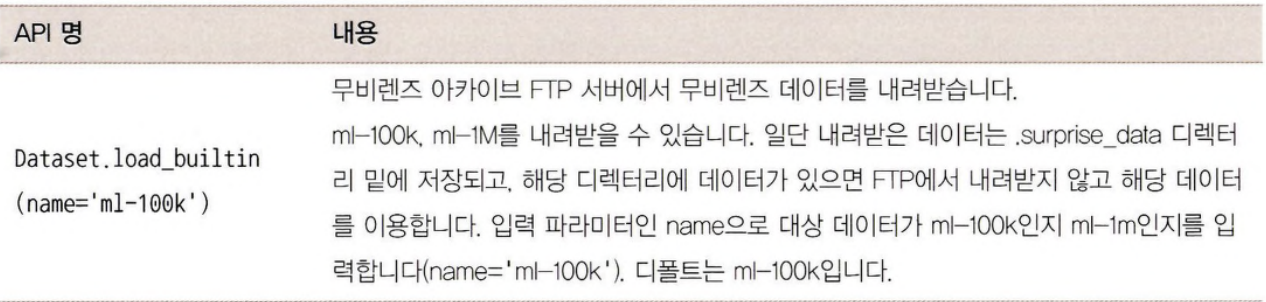

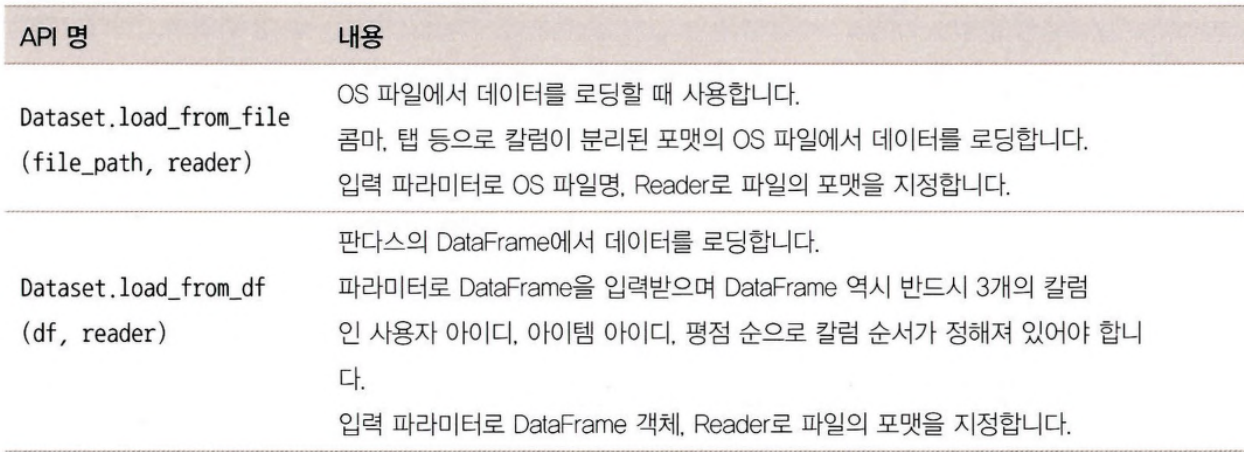

> OS 파일 데이터를 Surprise 데이터 세트로 로딩

- 먼저 OS 파일 로딩 시 주의할 점은 로딩되는 데이터 파일에 칼럼명을 가지는 헤더 문자열이 있어서는 안된다는 것


In [16]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
# ratings_noh.csv 파일로 언로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성.
ratings.to_csv('/content/ratings_noh.csv', index=False, header=False)

- 먼저 Dataset.load_from_file()을 적용하기 전에 Reader 클래스를 이용해 데이터 파일의 파싱 포맷을 정의해야 함
- Reader 클래스는 로딩될 ratings_noh.csv 파일의 파싱 정보를 알려주기 위해 사용됨
- Reader 클래스의 생성자에 각 필드의 칼럼명과 칼럼 분리문자, 그리고 최소~최대 평점을 입력해 객체를 생성하고, load_from_file()로 생성된 Reader 객체를 참조해 데이터 파일을 파싱하면서 로딩

<br>

- Reader 객체 생성 시에 Iine_format 인자로 user, item, rating, timestamp의 4개의 칼럼으로 데이터가 구성돼 있음을 명시했고, 각 칼럼의 분리 문자는 콤마, 평점의 단위는 0.5, 최대
평점은 5점으로 설정.

In [17]:
from surprise import Reader

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
data=Dataset.load_from_file('/content/ratings_noh.csv', reader=reader)

- Surprise 데이터 세트는 기본적으로 무비렌즈 데이터 형식을 따르므로 무비렌즈 데이터 형식이 아닌 다른 OS 파일의 경우 Reader 클래스를 먼저 설정해야 함

[Reader 클래스의 주요 생성 파라미터]

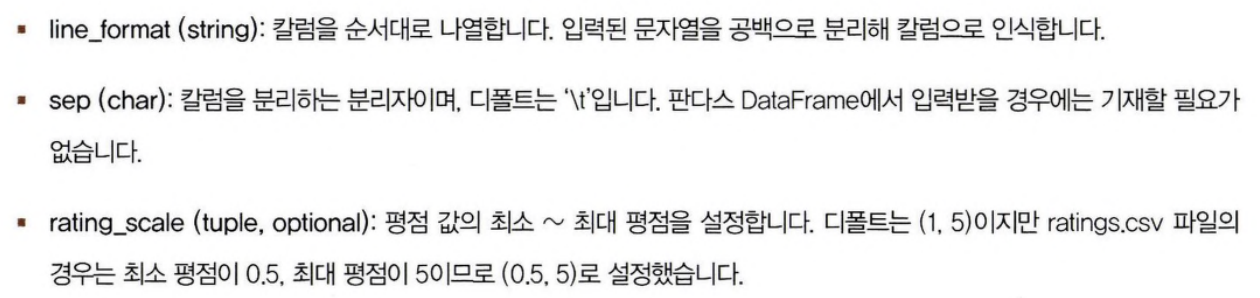

- 이제 SVD 행렬 분해 기법을 이용해 추천을 예측

In [18]:
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

# 수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

# 학습 데이터 세트로 학습하고 나서 테스트 데이터 세트로 평점 예측 후 RMSE 평가
algo.fit(trainset)
predictions = algo.test( testset )
accuracy.rmse(predictions)

RMSE: 0.8682


np.float64(0.8681952927143516)

> 판다스 DataFrame에서 Surprise 데이터 세트로 로딩

- Dataset.load_from_df()를 이용하면 판다스의 DataFrame에서도 Surprise 데이터 세트로 로딩할 수 있음

- 주의할 점은 DataFrame 역시 사용자 아이디, 아이템 아이디, 평점 칼럼 순서를 지켜야 한다는 것


In [19]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('/content/ratings.csv')
reader = Reader(rating_scale=(0.5, 5.0))

# ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset)
predictions = algo.test( testset )
accuracy.rmse(predictions)

RMSE: 0.8682


np.float64(0.8681952927143516)

###**Surprise 추천 알고리즘 클래스**

- SVD
- KNNBasic
- BaselineOnly
- SVD++
- NMF

--> Surprise SVD 비용 함수는 사용자 베이스라인 편향성을 감안한 평점 예측에 Regularization을 적용한 것

[SVD 클래스의 입력 파라미터]
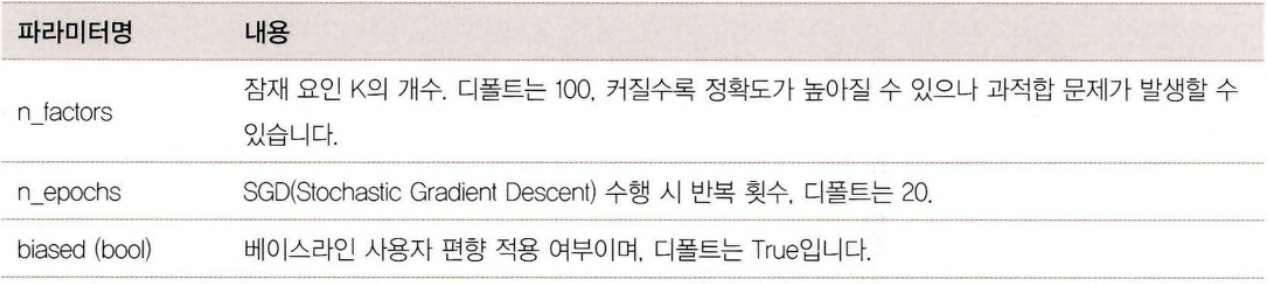

- n_factors와 n_epochs의 값을 변경해 튜닝할 수 있으나 튜닝 효과는 크지 않음
- biased의 경우 큰 이슈가 없는 한 디폴트인 True로 설정을 유지하는 것이 좋음

[추천 알고리즘의 예측 성능 벤치마크 결과]

- SVD++ 알고리즘의 RMSE, MAE 성적이 가장 좋지만, 상대적으로 시간이 너무 오래 걸려 데이터가 조금만 더 커져도 사용하기가 어려울 것으로 보임
- SVD++ 제외하면 SVD와 k-NN Baseline이 가장 성능 평가 수치가 좋음
- k-NN 자체는 성능이 상대적으로 뒤지지만, Baseline을 결합한 경우 성능 평가 수치가 대폭 향상
- Baseline의 의미는 각 개인이 평점을 부여하는 성향을 반영해 평점을 계산하는 방식

<br>

###**베이스라인 평점**

- 각 개인의 성향에 따라 같은 아이템이더라도 평가가 달라질 수 있음
- 따라서 이러한 개인의 성향을 반영해 아이템 평가에 펴냥성 요소를 반영하여 평점을 부과하는 것을 베이스라인 평점이라고 함
- 보통 베이스라인 평점은 전체 평균 평점 + 사용자 편향 점수 + 아이템 편향 점수 공식으로 계산됨

> 전체 평균 평점 = 모든 사용자의 아이템에 대한 평점을 평균한 값

> 사용자 편향 점수 = 사용자별 아이템 평점 평균 값 - 전체 평균 평점

> 아이템 편향 점수 = 아이템별 평점 평균 값 - 전체 평균 평점

<br>

###**교차 검증과 하이퍼 파라미터 튜닝**

- Surprise는 교차 검증과 하이퍼 파라미터 튜닝을 위해 사이킷런과 유사한 cross_validate()와 GridSearchCV 클래스 제공
- cross_validate() 함수는 surprise.model_selection 모듈 내에 존재하며, 폴드된 데이터 세트의 개수와 성능 측정 방법을 명시해 교차 검증 수행

In [21]:
from surprise.model_selection import cross_validate

# 판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv('/content/ratings.csv') # reading data in pandas df
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8688  0.8809  0.8679  0.8758  0.8726  0.8732  0.0048  
MAE (testset)     0.6697  0.6765  0.6686  0.6715  0.6695  0.6712  0.0028  
Fit time          1.50    1.65    1.40    1.34    1.31    1.44    0.12    
Test time         0.18    0.26    0.12    0.12    0.11    0.16    0.06    


{'test_rmse': array([0.86875695, 0.88092589, 0.86790862, 0.87578182, 0.87258328]),
 'test_mae': array([0.66974362, 0.67645239, 0.66859186, 0.67147973, 0.6695167 ]),
 'fit_time': (1.4999604225158691,
  1.6535823345184326,
  1.4021365642547607,
  1.3422033786773682,
  1.3081953525543213),
 'test_time': (0.18410110473632812,
  0.2566251754760742,
  0.12185192108154297,
  0.1154634952545166,
  0.11479949951171875)}

- Surprise의 GridSearchCV도 사이킷런의 GridSearchCV와 유사하게 교차 검증을 통한 하이퍼 파라미터 최적화 수행
- SVD의 경우 주로 점진적 하강 방식의 반복 횟수를 지정하는 n_epochs와 SVD 잠재 요인 K의 크기를 지정하는 n_factors를 튜닝

In [22]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs': [20, 40, 60], 'n_factors': [50, 100, 200] }

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

from surprise.model_selection import GridSearchCV

# 최고 RMSE Evaluation 점수와 그때의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8776388808022743
{'n_epochs': 20, 'n_factors': 50}


###**Surprise를 이용한 개인화 영화 추천 시스템 구축**

- Surprise 패키지로 학습된 추천 알고리즘을 기반으로 특정 사용자가 아지 평점을 매기지 않은 영화 중에서 개인 취향에 가장 적절한 영화를 추천

In [23]:
# 다음 코드는 train_test_split( )으로 분리되지 않는 데이터 세트에 fit( )을 호출해 오류가 발생합니다.
# data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
# algo = SVD(n_factors=50, random_state=0)
# algo.fit(data)

- 데이터 세트 전체를 학습 데이터로 사용하려면 DatasetAutoFolds 클래스를 이용

In [25]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
# DatasetAutoFolds 클래스를 ratings_noh.csv 파일 기반으로 생성.
data_folds = DatasetAutoFolds(ratings_file='/content/ratings_noh.csv', reader=reader)

# 전체 데이터를 학습 데이터로 생성함.
trainset = data_folds.build_full_trainset()

In [26]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

In [28]:
# 영화에 대한 상세 속성 정보 DataFrame 로딩
movies = pd.read_csv('/content/movies.csv')

# userId=9의 movieId 데이터를 추출해 movieId=42 데이터가 있는지 확인.
movieIds = ratings[ratings['userId']==9] ['movieId']
if movieIds[movieIds==42].count() == 0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


- movieId 42인 영화에 대해 userId 9 사용자의 추천 예상 평점은 predict() 메서트를 이용하면 알 수 있음
- 학습된 SVD 객체에서 predict() 메서드 내에 userID movieID 값을 입력해 주면 됨
- 단, 이 값은 모두 문자열 값이어야 함

In [29]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


In [30]:
def get_unseen_surprise(ratings, movies, userId):
  # 입력값으로 들어온 userid에 해당하는 사용자가 평점을 매긴 모든 영화를 리스트로 생성
  seen_movies = ratings[ratings['userId']== userId]['movieId'].tolist()
  # 모든 영화의 movield를 리스트로 생성.
  total_movies = movies['movieId'].tolist()

  # 모든 영화의 movield 중 이미 평점을 매긴 영화의 movield를 제외한 후 리스트로 생성
  unseen_movies= [movie for movie in total_movies if movie not in seen_movies]
  print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies),
        '전체 영화 수:', len(total_movies))

  return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


- recomm_movie_by_surprise() 함수를 새롭게 생성
- 이 함수는 인자로 학습이 완료된 추천 알고리즘 객체, 추천 대상 사용자 아이디, 추천 대상 영화의 리스트 객체, 그리고 추천 상위 N개 개수를 받음

In [31]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):

  # 알고리즘 객체의 predict() 메서드를 평점이 없는 영화에 반복 수행한 후 결과를 list 객체로 저장
  predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

  # predictions list 객체는 surprise의 Predictions 객체를 원소로 가지고 있음.
  # [Prediction(uid='9', iid='1 est=3.69), Prediction(uid='9', iid='2', est=2.98),,,,]

  # 이를 est 값으로 정렬하기 위해서 아래의 sortkey_est 함수를 정의함.
  # sortkey.est 함수는 list 객체의 sort() 함수의 키 값으로 사용되어 정렬 수행.
  def sortkey_est(pred):
    return pred.est

  # sortkey_est( ) 반환값의 내림 차순으로 정렬 수행하고 top_n개의 최상위 값 추출.
  predictions.sort(key=sortkey_est, reverse=True)
  top_predictions= predictions[:top_n]

  # top_n으로 추출된 영화의 정보 추출. 영화 아이디, 추천 예상 평점, 제목 추출
  top_movie_ids = [ int(pred.iid) for pred in top_predictions]
  top_movie_rating = [ pred.est for pred in top_predictions]
  top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']

  top_movie_preds = [ (id, title, rating) for id, title, rating in
                       zip(top_movie_ids, top_movie_titles, top_movie_rating)]

  return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)

print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
  print(top_movie[1], ":", top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122657
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957
